In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CLASSIFICAÇÃO DE SPAM — KNN vs SVM
Disciplina de IA | Professor Munif | Unicesumar 2026

[1/5] Carregando dataset...
     Dataset carregado do Google Drive!

     Total de mensagens : 5572
     Ham (não-spam)     : 4825
     Spam               : 747

[2/5] Pré-processando os dados...
     Treino : 4457 mensagens
     Teste  : 1115 mensagens
     TF-IDF : bigramas, max 5000 features, sublinear_tf=True

[3/5] Treinando os modelos...
     KNN treinado  (k=5, métrica cosseno)
     SVM treinado  (LinearSVC, C=1.0, hiperplano linear)

     Modelos salvos: modelo_knn.pkl | modelo_svm.pkl

[4/5] Avaliando os modelos...

        Acurácia  Precisão  Revocação  F1-Score
Modelo                                         
KNN       0.9704    0.9531     0.8188    0.8809
SVM       0.9830    0.9851     0.8859    0.9329

[5/5] Gerando gráficos...


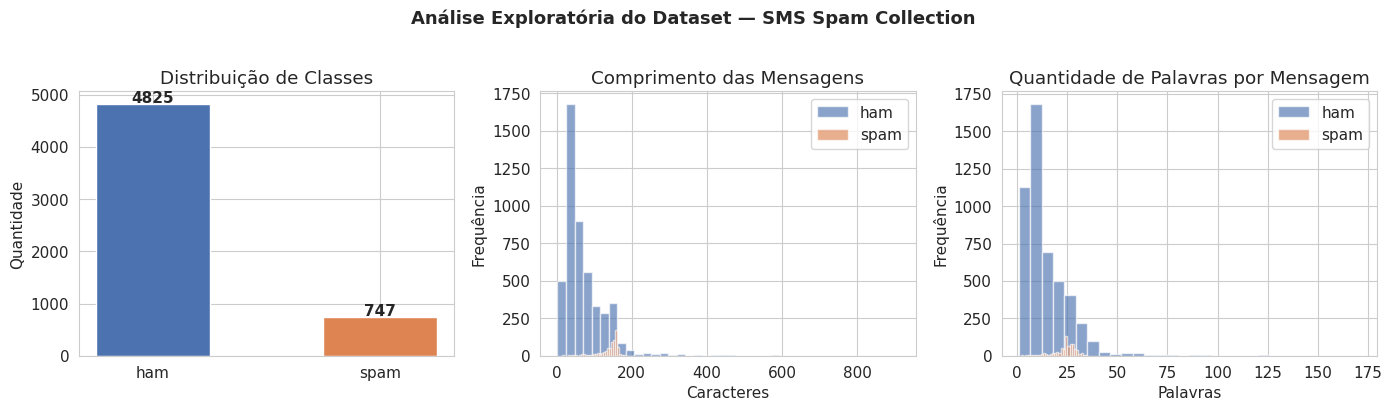

     fig1_dataset.png


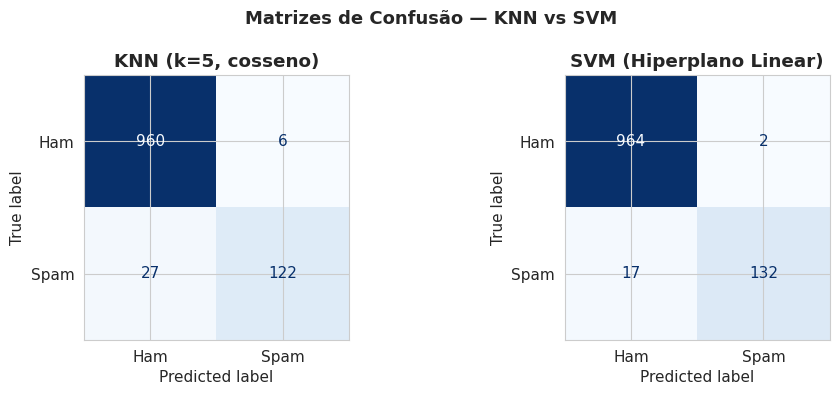

     fig2_confusion.png


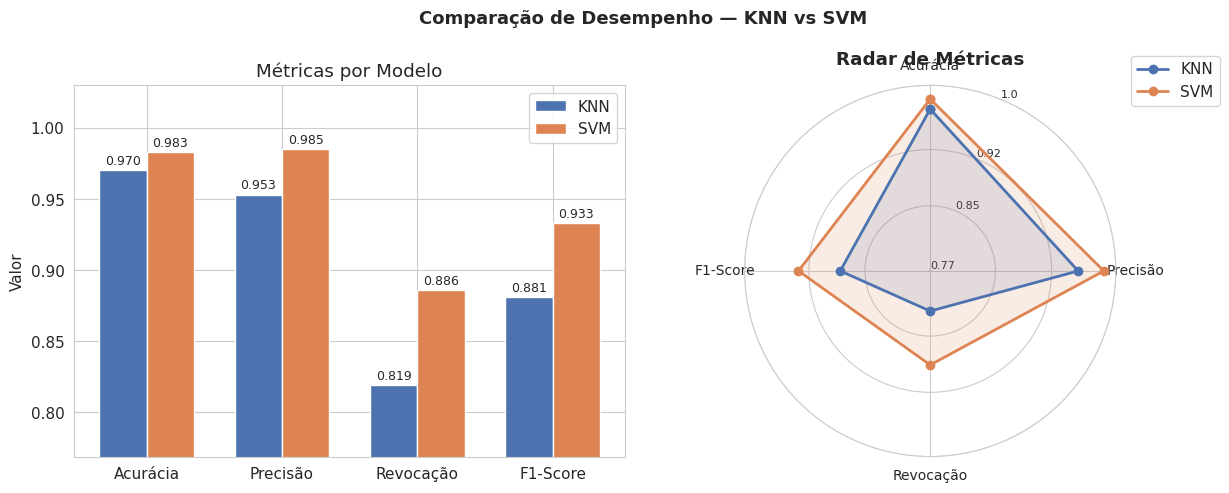

     fig3_comparacao.png

     Mensagem                                                   KNN      SVM   
     --------------------------------------------------------------------------
     Congratulations! You've won a FREE prize. Call now to...   SPAM     SPAM  
     Hey, are you coming to the meeting tomorrow at 3pm?        HAM      HAM   
     URGENT: Your account has been suspended. Click here t...   HAM      HAM   
     Can you pick up some milk on your way home?                HAM      HAM   
     FREE entry in 2 a weekly competition to win FA Cup fi...   SPAM     SPAM  
     What time does the train arrive?                           HAM      HAM   

RESUMO FINAL

  Melhor modelo (F1-Score): SVM

  KNN — F1: 0.8809 | Acurácia: 0.9704
  SVM — F1: 0.9329 | Acurácia: 0.9830

  Arquivos gerados:
    modelo_knn.pkl       — modelo KNN salvo
    modelo_svm.pkl       — modelo SVM salvo
    fig1_dataset.png     — análise exploratória
    fig2_confusion.png   — matrizes de confusão
    f

In [ ]:
"""
Disciplina de Inteligência Artificial, Professor Munif, Unicesumar 2026
Classificação de Spam com KNN e SVM
Dataset: SMS Spam Collection (UCI ML Repository)

Como obter o dataset:
  1. Acesse: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
  2. Faça download do arquivo 'spam.csv'
  3. Renomeie para 'SMSSpamCollection.csv' e coloque na mesma pasta deste script
  OU
  1. Acesse: https://archive.ics.uci.edu/dataset/228/sms+spam+collection
  2. Baixe e extraia o arquivo 'SMSSpamCollection' (sem extensão, separado por tab)
"""

# ============================================================
# 1. IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, warnings, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("CLASSIFICAÇÃO DE SPAM — KNN vs SVM")
print("Disciplina de IA | Professor Munif | Unicesumar 2026")
print("=" * 60)

# ============================================================
# 2. CARREGAMENTO DO DATASET
#    Aceita dois formatos comuns do SMS Spam Collection
# ============================================================
print("\n[1/5] Carregando dataset...")

df = pd.read_csv("/content/drive/MyDrive/spam.csv", encoding="latin-1")
col_label = "v1" if "v1" in df.columns else df.columns[0]
col_msg   = "v2" if "v2" in df.columns else df.columns[1]
df = df[[col_label, col_msg]].copy()
df.columns = ["label", "message"]
print("     Dataset carregado do Google Drive!")

# Limpeza básica
df = df[["label", "message"]].dropna()
df["label"] = df["label"].str.strip().str.lower()
df = df[df["label"].isin(["ham", "spam"])].reset_index(drop=True)

print(f"\n     Total de mensagens : {len(df)}")
print(f"     Ham (não-spam)     : {(df['label'] == 'ham').sum()}")
print(f"     Spam               : {(df['label'] == 'spam').sum()}")

# ============================================================
# 3. PRÉ-PROCESSAMENTO
# ============================================================
print("\n[2/5] Pré-processando os dados...")

# Features auxiliares para análise exploratória
df["msg_length"]   = df["message"].apply(len)
df["word_count"]   = df["message"].apply(lambda x: len(x.split()))
df["has_currency"] = df["message"].apply(
    lambda x: any(c in "$£€" for c in x)).astype(int)
df["pct_upper"]    = df["message"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))

# Codificação: ham=0, spam=1
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

X_text = df["message"]
y      = df["label_enc"]

# Divisão 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"     Treino : {len(X_train)} mensagens")
print(f"     Teste  : {len(X_test)} mensagens")
print(f"     TF-IDF : bigramas, max 5000 features, sublinear_tf=True")

# ============================================================
# 4. PIPELINES — TF-IDF + MODELO
# ============================================================
print("\n[3/5] Treinando os modelos...")

def make_tfidf():
    return TfidfVectorizer(
        strip_accents="unicode",
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )

# KNN — k=5, distância de cosseno (adequada para texto TF-IDF)
pipe_knn = Pipeline([
    ("tfidf", make_tfidf()),
    ("knn",   KNeighborsClassifier(n_neighbors=5, metric="cosine", n_jobs=-1))
])

# SVM — LinearSVC (hiperplano linear, maximiza margem entre classes)
pipe_svm = Pipeline([
    ("tfidf", make_tfidf()),
    ("svm",   LinearSVC(C=1.0, max_iter=2000, random_state=42))
])

pipe_knn.fit(X_train, y_train)
print("     KNN treinado  (k=5, métrica cosseno)")

pipe_svm.fit(X_train, y_train)
print("     SVM treinado  (LinearSVC, C=1.0, hiperplano linear)")

# Salva modelos
joblib.dump(pipe_knn, "modelo_knn.pkl")
joblib.dump(pipe_svm, "modelo_svm.pkl")
print("\n     Modelos salvos: modelo_knn.pkl | modelo_svm.pkl")

# ============================================================
# 5. AVALIAÇÃO
# ============================================================
print("\n[4/5] Avaliando os modelos...")

y_pred_knn = pipe_knn.predict(X_test)
y_pred_svm = pipe_svm.predict(X_test)

def get_metrics(y_true, y_pred, name):
    return {
        "Modelo"    : name,
        "Acurácia"  : accuracy_score(y_true, y_pred),
        "Precisão"  : precision_score(y_true, y_pred),
        "Revocação" : recall_score(y_true, y_pred),
        "F1-Score"  : f1_score(y_true, y_pred),
    }

m_knn = get_metrics(y_test, y_pred_knn, "KNN")
m_svm = get_metrics(y_test, y_pred_svm, "SVM")
df_metrics = pd.DataFrame([m_knn, m_svm]).set_index("Modelo")

print("\n" + "=" * 55)
print(df_metrics.to_string(float_format=lambda x: f"{x:.4f}"))
print("=" * 55)

# ============================================================
# 6. GRÁFICOS
# ============================================================
print("\n[5/5] Gerando gráficos...")

BLUE   = "#4C72B0"
ORANGE = "#DD8452"
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

# --- FIGURA 1: Análise exploratória -------------------------
fig1, axes = plt.subplots(1, 3, figsize=(14, 4))
fig1.suptitle("Análise Exploratória do Dataset — SMS Spam Collection",
              fontsize=13, fontweight="bold", y=1.02)

# 1a distribuição de classes
counts = df["label"].value_counts()
colors_bar = [BLUE if l == "ham" else ORANGE for l in counts.index]
axes[0].bar(counts.index, counts.values, color=colors_bar, edgecolor="white", width=0.5)
axes[0].set_title("Distribuição de Classes")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# 1b comprimento das mensagens
for lbl, color in zip(["ham", "spam"], [BLUE, ORANGE]):
    axes[1].hist(df[df["label"] == lbl]["msg_length"],
                 bins=40, alpha=0.65, label=lbl, color=color, edgecolor="white")
axes[1].set_title("Comprimento das Mensagens")
axes[1].set_xlabel("Caracteres")
axes[1].set_ylabel("Frequência")
axes[1].legend()

# 1c contagem de palavras
for lbl, color in zip(["ham", "spam"], [BLUE, ORANGE]):
    axes[2].hist(df[df["label"] == lbl]["word_count"],
                 bins=30, alpha=0.65, label=lbl, color=color, edgecolor="white")
axes[2].set_title("Quantidade de Palavras por Mensagem")
axes[2].set_xlabel("Palavras")
axes[2].set_ylabel("Frequência")
axes[2].legend()

plt.tight_layout()
plt.savefig("fig1_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print("     fig1_dataset.png")

# --- FIGURA 2: Matrizes de confusão -------------------------
fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle("Matrizes de Confusão — KNN vs SVM",
              fontsize=13, fontweight="bold")

for ax, y_pred, title in zip(axes,
                              [y_pred_knn, y_pred_svm],
                              ["KNN (k=5, cosseno)", "SVM (Hiperplano Linear)"]):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.savefig("fig2_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("     fig2_confusion.png")

# --- FIGURA 3: Comparação de métricas -----------------------
fig3 = plt.figure(figsize=(13, 5))
fig3.suptitle("Comparação de Desempenho — KNN vs SVM",
              fontsize=13, fontweight="bold")

metric_names = ["Acurácia", "Precisão", "Revocação", "F1-Score"]
metric_keys  = ["Acurácia", "Precisão", "Revocação", "F1-Score"]

# 3a — barras agrupadas
ax_bar = fig3.add_subplot(1, 2, 1)
x     = np.arange(len(metric_names))
width = 0.35
bars_k = ax_bar.bar(x - width/2, [m_knn[k] for k in metric_keys],
                    width, label="KNN", color=BLUE, edgecolor="white")
bars_s = ax_bar.bar(x + width/2, [m_svm[k] for k in metric_keys],
                    width, label="SVM", color=ORANGE, edgecolor="white")

ymin = min([m_knn[k] for k in metric_keys] + [m_svm[k] for k in metric_keys])
ax_bar.set_ylim(max(0, ymin - 0.05), 1.03)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names)
ax_bar.set_ylabel("Valor")
ax_bar.set_title("Métricas por Modelo")
ax_bar.legend()
for bar in list(bars_k) + list(bars_s):
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f"{h:.3f}", ha="center", va="bottom", fontsize=9)

# 3b — radar chart
ax_r = fig3.add_subplot(1, 2, 2, polar=True)
N      = len(metric_names)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(metric_names, fontsize=10)
radar_min = max(0.7, ymin - 0.05)
ax_r.set_ylim(radar_min, 1.0)
ticks = np.round(np.linspace(radar_min, 1.0, 4), 2)
ax_r.set_yticks(ticks)
ax_r.set_yticklabels([str(t) for t in ticks], fontsize=8)

for name, y_pred, color in [("KNN", y_pred_knn, BLUE), ("SVM", y_pred_svm, ORANGE)]:
    vals = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),   f1_score(y_test, y_pred)]
    vals += vals[:1]
    ax_r.plot(angles, vals, "o-", linewidth=2, label=name, color=color)
    ax_r.fill(angles, vals, alpha=0.15, color=color)

ax_r.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax_r.set_title("Radar de Métricas", fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("fig3_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("     fig3_comparacao.png")

# ============================================================
# 7. EXEMPLOS DE CLASSIFICAÇÃO
# ============================================================
sample_msgs = [
    "Congratulations! You've won a FREE prize. Call now to claim!",
    "Hey, are you coming to the meeting tomorrow at 3pm?",
    "URGENT: Your account has been suspended. Click here to restore.",
    "Can you pick up some milk on your way home?",
    "FREE entry in 2 a weekly competition to win FA Cup final tickets!",
    "What time does the train arrive?",
]

print(f"\n     {'Mensagem':<56} {'KNN':^8} {'SVM':^8}")
print("     " + "-" * 74)
for msg in sample_msgs:
    pk = "SPAM" if pipe_knn.predict([msg])[0] == 1 else "HAM "
    ps = "SPAM" if pipe_svm.predict([msg])[0] == 1 else "HAM "
    s  = (msg[:53] + "...") if len(msg) > 56 else msg
    print(f"     {s:<56} {pk:^8} {ps:^8}")

# ============================================================
# 8. RESUMO FINAL
# ============================================================
winner = "SVM" if m_svm["F1-Score"] >= m_knn["F1-Score"] else "KNN"
print("\n" + "=" * 60)
print("RESUMO FINAL")
print("=" * 60)
print(f"\n  Melhor modelo (F1-Score): {winner}")
print(f"\n  KNN — F1: {m_knn['F1-Score']:.4f} | Acurácia: {m_knn['Acurácia']:.4f}")
print(f"  SVM — F1: {m_svm['F1-Score']:.4f} | Acurácia: {m_svm['Acurácia']:.4f}")
print("\n  Arquivos gerados:")
print("    modelo_knn.pkl       — modelo KNN salvo")
print("    modelo_svm.pkl       — modelo SVM salvo")
print("    fig1_dataset.png     — análise exploratória")
print("    fig2_confusion.png   — matrizes de confusão")
print("    fig3_comparacao.png  — comparação KNN vs SVM")
print("=" * 60)
